# Cetacean Detection — Model vs Expert Comparison (ARBAS) 

Compares model predictions (5-second segments) against expert annotations (1-minute WAV files).

- `expert_annotated` now derived from a merge **indicator**, not from a value column that is later `fillna`-ed — so a WAV the expert listened to but found *empty* is correctly `both_negative`, not `no_expert_label`.
- Thousands-separator regex no longer mangles legit values like `2.500` → `2500`; it only fires on true multi-group numbers.
- `exp_top_species` ties reported; `idxmax` first-wins behaviour made explicit.
- Model-side duplicate `(wav_name, segment_index)` guard added.
- Spectrogram glob anchored so a stem can't match a longer stem as a substring.
- Summary plot (c) set-difference precedence bug fixed.

### Resolution mismatch
Expert labels are at 1-minute resolution → broadcast to all 12 × 5 s segments of that WAV.

### Three prediction strategies (same MLP, different post-hoc decoding)
| Strategy | How it decides | Failure mode |
|---|---|---|
| `argmax` | plain softmax argmax | over-predicts background |
| `vec` | per-class `w·logit + b`, inv-freq weighted | hallucinates on ambiguous segments |
| `pr` | argmax among species clearing F1-optimal threshold, else background | lowest hallucination |

### Consensus (`pred_consensus`)
All three agree → that label; else `'uncertain'`.

### Species mapping
- `Delphinidae_unknown` ↔ `Ambig`; `background` ↔ all expert votes 0
- Common: Dd Gg Gm Oo Pm Sc Tt Ambig
- Only model: Ba Bp · Only expert: Dc Lo Zc Bb

In [1]:
# ── 0. Imports & paths ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── EDIT THESE ───────────────────────────────────────────────────────────────
MY_PREDICTIONS_CSV = r"/data2/mromaniuc/cet-det/inference/inference_arbas/predictions/arbas_predictions_l4.csv"
EXPERT_MAY_XLSX    = r"/data2/mromaniuc/cet-det/inference/inference_arbas/comparison/expert_validated_data/XIULOS_MAIG_TOTAL.xlsx"
EXPERT_AUG_XLSX    = r"/data2/mromaniuc/cet-det/inference/inference_arbas/comparison/expert_validated_data/XiulosAGOST_TOTAL.xlsx"
SPECTROGRAM_DIR    = r"/data2/mromaniuc/cet-det/inference/inference_arbas/spectrograms/spectrograms"
OUTPUT_CSV         = "arbas_comparison_5s_v3.csv"

EXPERT_MAY_SHEET   = 'in'
EXPERT_AUG_SHEET   = 'XiulosAGOST_TOTAL'
# ─────────────────────────────────────────────────────────────────────────────

# ── Separator-agnostic basename ──────────────────────────────────────────────
# A Windows path string ('D:\\dir\\file.wav') on a Linux pathlib does NOT split
# on backslash — Path('D:\\...').name returns the whole string. This is the
# classic cause of zero-match merges. Normalise both separators ourselves.
def normalise_wav_name(x):
    """Return just 'XXXX.wav' from any path, Windows or POSIX, with cleanup."""
    if pd.isna(x):
        return None
    s = str(x).strip().strip('"').strip("'")
    s = s.replace('\\\\', '/').replace('\\', '/')   # collapse Windows separators
    s = s.split('/')[-1]                             # take basename
    s = s.strip().lower()                            # case-insensitive match
    if not s.endswith('.wav'):
        s = s + '.wav'
    return s

print("Config loaded. Quick self-test of normalise_wav_name:")
for t in [r'D:\\IM-23-ARBAS\\Soundtrap 6338\\6338.240528160459.wav',
          '6338.240528160459.wav', ' 6312.240806141558 ']:
    print(f"  {t!r:70s} -> {normalise_wav_name(t)!r}")

Config loaded. Quick self-test of normalise_wav_name:
  'D:\\\\IM-23-ARBAS\\\\Soundtrap 6338\\\\6338.240528160459.wav'         -> '6338.240528160459.wav'
  '6338.240528160459.wav'                                                -> '6338.240528160459.wav'
  ' 6312.240806141558 '                                                  -> '6312.240806141558.wav'


In [2]:
# ── 1. Load model predictions ────────────────────────────────────────────────
df_mine = pd.read_csv(MY_PREDICTIONS_CSV)
print(f"Raw CSV: {len(df_mine):,} rows, {df_mine.shape[1]} columns")

# Identify the wav-path column robustly
PATH_COL = next((c for c in ['wav_path', 'wav_name', 'file', 'filename', 'path']
                 if c in df_mine.columns), None)
assert PATH_COL is not None, f"No path column found. Columns: {list(df_mine.columns)}"
print(f"Using '{PATH_COL}' as the wav path column.")

df_mine['wav_name'] = df_mine[PATH_COL].apply(normalise_wav_name)
print(f"Example normalised wav_name: {df_mine['wav_name'].iloc[0]!r}")

# Rename raw prob columns to short codes
# top_predicted_class / top_logit_score are Perch's raw output — IGNORED throughout
PROB_RENAME = {
    'prob_Balaenoptera_acutorostrata': 'prob_Ba',
    'prob_Balaenoptera_physalus':      'prob_Bp',
    'prob_Delphinidae_unknown':        'prob_Ambig',
    'prob_Delphinus_delphis':          'prob_Dd',
    'prob_Globicephala_melas':         'prob_Gm',
    'prob_Grampus_griseus':            'prob_Gg',
    'prob_Orcinus_orca':               'prob_Oo',
    'prob_Physeter_macrocephalus':     'prob_Pm',
    'prob_Stenella_coeruleoalba':      'prob_Sc',
    'prob_Tursiops_truncatus':         'prob_Tt',
    'prob_background':                 'prob_bg',
}
df_mine.rename(columns=PROB_RENAME, inplace=True)

CETACEAN_PROB_COLS = ['prob_Ba','prob_Bp','prob_Ambig','prob_Dd','prob_Gm',
                      'prob_Gg','prob_Oo','prob_Pm','prob_Sc','prob_Tt']
missing_probs = [c for c in CETACEAN_PROB_COLS + ['prob_bg'] if c not in df_mine.columns]
assert not missing_probs, f"Missing probability columns after rename: {missing_probs}"

# Strategy columns (already in CSV)
STRAT_COLS = ['pred_argmax', 'pred_vec', 'pred_pr']
for col in STRAT_COLS:
    assert col in df_mine.columns, f"Strategy column '{col}' not in CSV. " \
        f"Columns: {[c for c in df_mine.columns if c.startswith('pred')]}"

# v4: guard against duplicate (wav_name, segment_index) on the MODEL side.
# The expert dup-guard in cell 2 only protects the right-hand frame; a dup here
# would double-count segments in every breakdown and the viewer.
if 'segment_index' in df_mine.columns:
    seg_dups = df_mine.duplicated(subset=['wav_name', 'segment_index']).sum()
    if seg_dups:
        print(f"  ⚠ {seg_dups} duplicate (wav_name, segment_index) row(s) in model CSV "
              f"— keeping first.")
        df_mine = df_mine.drop_duplicates(subset=['wav_name', 'segment_index'],
                                          keep='first').reset_index(drop=True)

# Normalise strategy label strings (strip whitespace, unify background spelling)
for col in STRAT_COLS:
    df_mine[col] = df_mine[col].astype(str).str.strip()

# Consensus: all three agree → that label; else 'uncertain'
def make_consensus(row):
    labels = {row['pred_argmax'], row['pred_vec'], row['pred_pr']}
    return row['pred_argmax'] if len(labels) == 1 else 'uncertain'
df_mine['pred_consensus'] = df_mine.apply(make_consensus, axis=1)

# Detection flags per strategy
for s in ['argmax', 'vec', 'pr', 'consensus']:
    df_mine[f'cetacean_{s}'] = df_mine[f'pred_{s}'] != 'background'
# uncertain is neither background nor a clean detection → not a confirmed detection
df_mine.loc[df_mine['pred_consensus'] == 'uncertain', 'cetacean_consensus'] = False

# Max cetacean prob — DISPLAY/FILTER only, never used for classification
df_mine['max_cetacean_prob'] = df_mine[CETACEAN_PROB_COLS].max(axis=1)

print(f"\nLoaded {len(df_mine):,} segments from {df_mine['wav_name'].nunique():,} WAV files")
for s in ['argmax', 'vec', 'pr', 'consensus']:
    n = df_mine[f'cetacean_{s}'].sum()
    print(f"  {s:10s}: {n:,} cetacean ({100*n/len(df_mine):.1f}%)")
print(f"  {'uncertain':10s}: {(df_mine['pred_consensus']=='uncertain').sum():,}")

df_mine[['wav_name','segment_index','offset_s',
         'pred_argmax','pred_vec','pred_pr','pred_consensus']].head(8)

Raw CSV: 117,650 rows, 23 columns
Using 'wav_path' as the wav path column.
Example normalised wav_name: '6338.240528160459.wav'

Loaded 117,650 segments from 9,805 WAV files
  argmax    : 37,916 cetacean (32.2%)
  vec       : 57,351 cetacean (48.7%)
  pr        : 18,349 cetacean (15.6%)
  consensus : 18,348 cetacean (15.6%)
  uncertain : 39,189


,wav_name,segment_index,offset_s,pred_argmax,pred_vec,pred_pr,pred_consensus
0,6338.240528160459.wav,0,0.0,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown
1,6338.240528160459.wav,1,5.0,Delphinidae_unknown,Delphinidae_unknown,background,uncertain
2,6338.240528160459.wav,2,10.0,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown
3,6338.240528160459.wav,3,15.0,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown
4,6338.240528160459.wav,4,20.0,background,Delphinidae_unknown,background,uncertain
5,6338.240528160459.wav,5,25.0,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown
6,6338.240528160459.wav,6,30.0,background,Delphinidae_unknown,background,uncertain
7,6338.240528160459.wav,7,35.0,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown,Delphinidae_unknown


In [3]:
# ── 2. Load expert annotations ───────────────────────────────────────────────
# May    : sheet 'in'                (single sheet)
# August : sheet 'XiulosAGOST_TOTAL' (ignore 'Hoja1')

EXPERT_VOTE_RENAME = {
    'Ambig_votes': 'exp_Ambig',
    'Bb_votes':    'exp_Bb',   # Berardius bairdii — not in model vocab
    'Dc_votes':    'exp_Dc',   # Delphinus capensis — not in model vocab
    'Dd_votes':    'exp_Dd',
    'Gg_votes':    'exp_Gg',
    'Gm_votes':    'exp_Gm',
    'Lo_votes':    'exp_Lo',   # Lagenorhynchus obliquidens — not in model vocab
    'Oo_votes':    'exp_Oo',
    'Pm_votes':    'exp_Pm',
    'Sc_votes':    'exp_Sc',
    'Tt_votes':    'exp_Tt',
    'Zc_votes':    'exp_Zc',   # Ziphius cavirostris — not in model vocab
}
EXP_VOTE_COLS = list(EXPERT_VOTE_RENAME.values())

# PAMGuard vote counts live in [0, ~10). Many cells were corrupted by a
# number-format / locale artefact that INFLATED the value by a power of 10:
# the true 6.6773 was stored as the float 6.677e16 and displayed via a '#,##0'
# format as '66.773.333.333.333.300'. The corruption is purely multiplicative
# by 10**k, so it shifts the exponent but preserves the significant digits.
# Recovery = read the mantissa: divide the magnitude by 10 until it is < VOTE_MAX.
#
# v4's mistake: it CLAMPED every >100 cell to 0, deleting real detections
# wholesale (931 Gg, 695 Tt cells in August alone). v5 recovers them instead.
VOTE_MAX = 10.0   # guard output upper bound; values >= this are treated as inflated

def recover_vote(x):
    """Undo power-of-10 inflation on a single vote cell. Clean values pass through."""
    if pd.isna(x):
        return 0.0
    # Accept either a float (pandas already parsed the inflated value) or a string.
    try:
        f = float(str(x).strip().strip('"').strip("'").replace(',', '.'))
    except (ValueError, TypeError):
        return 0.0
    if f == 0.0:
        return 0.0
    sign = -1.0 if f < 0 else 1.0
    f = abs(f)
    while f >= VOTE_MAX:      # bring mantissa back into [0, VOTE_MAX)
        f /= 10.0
    return sign * f

def clean_vote_series(s):
    """Vectorised recover_vote with a count of how many cells were corrected."""
    raw = pd.to_numeric(s.astype(str).str.strip().str.replace(',', '.', regex=False),
                        errors='coerce')
    n_inflated = int((raw.abs() >= VOTE_MAX).sum())
    out = s.apply(recover_vote)
    return out, n_inflated

def load_expert_sheet(path, sheet_name):
    df = pd.read_excel(path, sheet_name=sheet_name)
    df.columns = [str(c).strip() for c in df.columns]   # strip header whitespace

    fname_col = next((c for c in df.columns
                      if c.strip().upper() in ('ARXIU', 'FILENAME', 'WAV', 'FILE')), None)
    if fname_col is None:
        raise ValueError(f"No filename column in {Path(path).name}/{sheet_name}. "
                         f"Columns: {list(df.columns)}")
    df.rename(columns={fname_col: 'wav_name_raw'}, inplace=True)
    df['wav_name'] = df['wav_name_raw'].apply(normalise_wav_name)

    df.rename(columns=EXPERT_VOTE_RENAME, inplace=True)
    audit = {}
    for col in EXP_VOTE_COLS:
        if col in df.columns:
            df[col], n_inflated = clean_vote_series(df[col])
            if n_inflated:
                audit[col] = n_inflated
        else:
            df[col] = 0.0   # species column absent in this sheet

    if audit:
        total = sum(audit.values())
        print(f"  {Path(path).name}: recovered {total} inflated vote cell(s) "
              f"(power-of-10 artefact): " +
              ", ".join(f"{k.replace('exp_','')}={v}" for k, v in sorted(audit.items())))

    df['source'] = Path(path).stem
    df = df[df['wav_name'].notna()].copy()
    df['exp_cetacean_detected'] = df[EXP_VOTE_COLS].sum(axis=1) > 0

    # idxmax returns the FIRST column on ties — report how often that happens.
    vote_mat = df[EXP_VOTE_COLS]
    row_max = vote_mat.max(axis=1)
    n_ties = ((vote_mat.eq(row_max, axis=0).sum(axis=1) > 1)
              & df['exp_cetacean_detected']).sum()
    if n_ties:
        print(f"  ⚠ {Path(path).name}/{sheet_name}: {n_ties} detected row(s) have a "
              f"top-species tie; idxmax breaks ties by column order.")

    df['exp_top_species'] = vote_mat.idxmax(axis=1).str.replace('exp_', '')
    df.loc[~df['exp_cetacean_detected'], 'exp_top_species'] = 'background'

    # Post-recovery sanity: nothing should exceed the guard ceiling now.
    still_big = (df[EXP_VOTE_COLS] >= VOTE_MAX).any(axis=1).sum()
    if still_big:
        print(f"  ⚠ {Path(path).name}: {still_big} row(s) still >= {VOTE_MAX} after "
              f"recovery — inspect manually.")
    return df

df_exp_may = load_expert_sheet(EXPERT_MAY_XLSX, EXPERT_MAY_SHEET)
df_exp_aug = load_expert_sheet(EXPERT_AUG_XLSX, EXPERT_AUG_SHEET)

print(f"\nMay   : {len(df_exp_may):,} rows  ({df_exp_may['exp_cetacean_detected'].sum()} cetacean)")
print(f"August: {len(df_exp_aug):,} rows  ({df_exp_aug['exp_cetacean_detected'].sum()} cetacean)")

# Guard against duplicate WAV names within the expert data (would inflate the merge)
df_expert = pd.concat([df_exp_may, df_exp_aug], ignore_index=True)
dups = df_expert['wav_name'].duplicated().sum()
if dups:
    print(f"  ⚠ {dups} duplicate wav_name(s) across expert sheets — keeping first.")
    df_expert = df_expert.drop_duplicates(subset='wav_name', keep='first')
print(f"Total : {len(df_expert):,} unique annotated WAVs")

df_expert[['wav_name','source','exp_cetacean_detected','exp_top_species'] + EXP_VOTE_COLS].head()

  XIULOS_MAIG_TOTAL.xlsx: recovered 191 inflated vote cell(s) (power-of-10 artefact): Dc=35, Dd=26, Gg=75, Lo=7, Oo=1, Sc=13, Tt=34
  XiulosAGOST_TOTAL.xlsx: recovered 2545 inflated vote cell(s) (power-of-10 artefact): Dc=412, Dd=196, Gg=933, Lo=46, Oo=8, Sc=255, Tt=695
  ⚠ XiulosAGOST_TOTAL.xlsx/XiulosAGOST_TOTAL: 2 detected row(s) have a top-species tie; idxmax breaks ties by column order.

May   : 4,062 rows  (115 cetacean)
August: 4,005 rows  (1704 cetacean)
Total : 8,067 unique annotated WAVs


,wav_name,source,exp_cetacean_detected,exp_top_species,exp_Ambig,exp_Bb,exp_Dc,exp_Dd,exp_Gg,exp_Gm,exp_Lo,exp_Oo,exp_Pm,exp_Sc,exp_Tt,exp_Zc
0,6338.240528160459.wav,XIULOS_MAIG_TOTAL,False,background,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
1,6338.240528160559.wav,XIULOS_MAIG_TOTAL,False,background,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
2,6338.240528160659.wav,XIULOS_MAIG_TOTAL,False,background,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
3,6338.240528160759.wav,XIULOS_MAIG_TOTAL,True,Gg,0.0,0.0,0.509333,0.333333,1.380000,0.0,0.242667,0.197333,0.0,0.116000,0.221333,0.0
4,6338.240528160859.wav,XIULOS_MAIG_TOTAL,True,Gg,0.0,0.0,0.869333,0.414667,2.166667,0.0,0.005333,0.000000,0.0,0.090667,0.453333,0.0


In [4]:
# ── 2b. KEY-OVERLAP DIAGNOSTIC (catches merge mismatches before they bite) ──
mine_keys = set(df_mine['wav_name'].dropna().unique())
exp_keys  = set(df_expert['wav_name'].dropna().unique())

overlap = mine_keys & exp_keys
print(f"Model WAVs           : {len(mine_keys):,}")
print(f"Expert WAVs          : {len(exp_keys):,}")
print(f"Overlapping WAVs      : {len(overlap):,}")
print(f"In expert, not model : {len(exp_keys - mine_keys):,}")
print(f"In model, not expert : {len(mine_keys - exp_keys):,}")

if len(overlap) == 0:
    print("\n❌ ZERO OVERLAP — the merge will be empty. Inspect sample keys:")
    print("  model :", sorted(mine_keys)[:3])
    print("  expert:", sorted(exp_keys)[:3])
    print("  → check separators, casing, trailing chars, or .wav suffix.")
else:
    print(f"\n✓ Overlap looks good. Sample matched keys: {sorted(overlap)[:3]}")

Model WAVs           : 9,805
Expert WAVs          : 8,067
Overlapping WAVs      : 8,067
In expert, not model : 0
In model, not expert : 1,738

✓ Overlap looks good. Sample matched keys: ['6312.240806141558.wav', '6312.240806141658.wav', '6312.240806141758.wav']


In [5]:
# ── 3. Merge: broadcast expert 1-min label → all 5 s segments of that WAV ───
EXPERT_KEEP = (['wav_name', 'exp_cetacean_detected', 'exp_top_species',
                'Encounter_Classification', 'source'] + EXP_VOTE_COLS)
EXPERT_KEEP = [c for c in EXPERT_KEEP if c in df_expert.columns]

# v4: derive `expert_annotated` from the merge INDICATOR, not from a value column.
# Previously expert_annotated = exp_cetacean_detected.notna(), but that column is
# fillna(False)-ed right after, and — more importantly — a WAV the expert listened
# to but found EMPTY has exp_cetacean_detected == False, which is semantically a
# `both_negative`, NOT a `no_expert_label`. Using _merge keeps the two distinct.
df = df_mine.merge(df_expert[EXPERT_KEEP], on='wav_name', how='left', indicator=True)
df['expert_annotated'] = df['_merge'] == 'both'
df.drop(columns='_merge', inplace=True)

# Fill expert columns for non-annotated rows so downstream code is safe
for col in EXP_VOTE_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(0.0)
# For annotated rows exp_cetacean_detected is already True/False; for
# non-annotated rows it is NaN -> fill False (no detection claimed).
df['exp_cetacean_detected'] = df['exp_cetacean_detected'].fillna(False).astype(bool)
df['exp_top_species'] = df['exp_top_species'].fillna('no_label')

print(f"Total segments           : {len(df):,}")
print(f"  With expert annotation : {df['expert_annotated'].sum():,}")
print(f"  Without                : {(~df['expert_annotated']).sum():,}")
print(f"  Unique annotated WAVs  : {df[df['expert_annotated']]['wav_name'].nunique():,}")

# Sanity: annotated rows where expert found nothing are legit both_negative material.
n_ann_empty = ((df['expert_annotated']) & (~df['exp_cetacean_detected'])).sum()
print(f"  Annotated but empty    : {n_ann_empty:,}  (these are valid both_negative, not no_label)")

assert df['expert_annotated'].sum() > 0, \
    "Still zero annotated segments — re-run the 2b diagnostic and fix key matching."

Total segments           : 117,650
  With expert annotation : 96,794
  Without                : 20,856
  Unique annotated WAVs  : 8,067
  Annotated but empty    : 74,966  (these are valid both_negative, not no_label)


# Cetacean Detection — WAV-level Evaluation
## Custom evaluation at the resolution the expert actually annotated

Expert labels are **per 1-minute WAV**; the model predicts **per 5-second segment**.
We reconcile the mismatch by aggregating upward to WAV level before scoring:

| Concept | Definition |
|---|---|
| **Model detects WAV** | ≥ 1 of its 5 s segments has `pred_consensus` ∈ any cetacean species (incl. Ambig) |
| **Model negative WAV** | all segments are `background` or `uncertain` — uncertain is **not** a detection |
| **True positive (TP)** | expert positive AND model detects |
| **False negative (FN)** | expert positive AND model does not detect |
| **True negative (TN)** | expert negative AND model does not detect |
| **False positive (FP)** | expert negative AND model detects |

Only WAVs with `expert_annotated = True` enter any metric.  
WAVs the model ran on but the expert never labelled are excluded.

> **Note on species labels in `pred_consensus`:** the strategy columns use the raw
> long-form decoder names (`Tursiops_truncatus`, `Delphinidae_unknown`, …).
> Cell A normalises these to short codes (`Tt`, `Ambig`, …) so they align with
> the expert species names throughout.


In [6]:
# ── A. WAV-level aggregation ─────────────────────────────────────────────────
# Retain only annotated segments.
ann = df[df['expert_annotated']].copy()

# ── A1. Normalise pred_consensus to short codes ───────────────────────────────
# pred_argmax / pred_vec / pred_pr (and therefore pred_consensus) carry the raw
# long-form names from the decoder (e.g. 'Tursiops_truncatus').  The prob_*
# columns were renamed to short codes ('prob_Tt') in cell 1, but the strategy
# label columns were not.  Build the mapping from PROB_RENAME and apply it.
SP_LONG_TO_SHORT = {k.replace('prob_', ''): v.replace('prob_', '')
                    for k, v in PROB_RENAME.items()
                    if v != 'prob_bg'}
# e.g. {'Tursiops_truncatus': 'Tt', 'Delphinidae_unknown': 'Ambig', ...}
# 'background' and 'uncertain' are not in the mapping — they pass through unchanged.

def normalise_consensus(label):
    return SP_LONG_TO_SHORT.get(label, label)

ann = ann.copy()
ann['pred_consensus'] = ann['pred_consensus'].map(normalise_consensus)

# Quick sanity: show unique values after normalisation
print("Unique pred_consensus values after normalisation:")
print(sorted(ann['pred_consensus'].unique()))

# ── A2. Define cetacean label set (short codes) ───────────────────────────────
SHARED_SPECIES    = ['Dd', 'Gg', 'Gm', 'Oo', 'Pm', 'Sc', 'Tt', 'Ambig']
CETACEAN_LABELS   = set(SP_LONG_TO_SHORT.values())   # all non-background species

# ── A3. Expert truth per WAV (same for every 5 s segment of that WAV) ─────────
exp_wav = (ann.groupby('wav_name', sort=False)
              .agg(exp_positive    = ('exp_cetacean_detected', 'first'),
                   exp_top_species = ('exp_top_species',       'first'))
              .reset_index())

# ── A4. Model detection per WAV ───────────────────────────────────────────────
def wav_model_flag(grp):
    """True if any segment fires a consensus cetacean label."""
    return grp['pred_consensus'].isin(CETACEAN_LABELS).any()

def wav_model_species_majority(grp):
    """Most common consensus cetacean label among firing segments (or NaN)."""
    hits = grp.loc[grp['pred_consensus'].isin(CETACEAN_LABELS), 'pred_consensus']
    return hits.mode().iloc[0] if len(hits) else float('nan')

def wav_model_species_any(grp):
    """Comma-joined sorted list of all distinct cetacean labels in this WAV."""
    hits = sorted(grp.loc[grp['pred_consensus'].isin(CETACEAN_LABELS),
                           'pred_consensus'].unique())
    return ', '.join(hits) if hits else ''

model_wav = (ann.groupby('wav_name', sort=False)
                .apply(lambda g: pd.Series({
                    'model_positive':    wav_model_flag(g),
                    'model_sp_majority': wav_model_species_majority(g),
                    'model_sp_any':      wav_model_species_any(g),
                    'n_segments':        len(g),
                    'n_cetacean_segs':   int(g['pred_consensus'].isin(CETACEAN_LABELS).sum()),
                    'n_uncertain_segs':  int((g['pred_consensus'] == 'uncertain').sum()),
                }), include_groups=False)
                .reset_index())

wav = exp_wav.merge(model_wav, on='wav_name', how='inner')

# ── A5. Outcome quadrant ──────────────────────────────────────────────────────
def outcome(row):
    ep, mp = bool(row['exp_positive']), bool(row['model_positive'])
    if ep  and mp:  return 'TP'
    if ep  and not mp: return 'FN'
    if not ep and mp:  return 'FP'
    return 'TN'
wav['outcome'] = wav.apply(outcome, axis=1)

cts = wav['outcome'].value_counts()
TP = int(cts.get('TP', 0)); FN = int(cts.get('FN', 0))
FP = int(cts.get('FP', 0)); TN = int(cts.get('TN', 0))

recall      = TP / (TP + FN) if (TP + FN) else float('nan')
precision   = TP / (TP + FP) if (TP + FP) else float('nan')
specificity = TN / (TN + FP) if (TN + FP) else float('nan')
f1 = 2*precision*recall / (precision+recall) if (precision and recall) else float('nan')

print(f"\nWAV-level evaluation  ({len(wav):,} annotated WAVs)\n")
print(f"  Expert positive : {TP+FN:,}   Expert negative : {TN+FP:,}\n")
print(f"  TP={TP:,}  FN={FN:,}  FP={FP:,}  TN={TN:,}\n")
print(f"  Recall      (sensitivity) : {recall:.3f}  ({TP}/{TP+FN} expert-positive WAVs caught)")
print(f"  Precision                 : {precision:.3f}  ({TP}/{TP+FP} model detections correct)")
print(f"  Specificity               : {specificity:.3f}  ({TN}/{TN+FP} expert-negative WAVs silent)")
print(f"  F1                        : {f1:.3f}")
n_unc_only = int(((wav['n_uncertain_segs'] > 0) & ~wav['model_positive']).sum())
print(f"\n  WAVs with uncertain-only segs (no cetacean consensus): {n_unc_only} (counted as negative)")


Unique pred_consensus values after normalisation:
['Ambig', 'Bp', 'Dd', 'Gg', 'Oo', 'Tt', 'background', 'uncertain']

WAV-level evaluation  (8,067 annotated WAVs)

  Expert positive : 1,819   Expert negative : 6,248

  TP=458  FN=1,361  FP=3,349  TN=2,899

  Recall      (sensitivity) : 0.252  (458/1819 expert-positive WAVs caught)
  Precision                 : 0.120  (458/3807 model detections correct)
  Specificity               : 0.464  (2899/6248 expert-negative WAVs silent)
  F1                        : 0.163

  WAVs with uncertain-only segs (no cetacean consensus): 3392 (counted as negative)


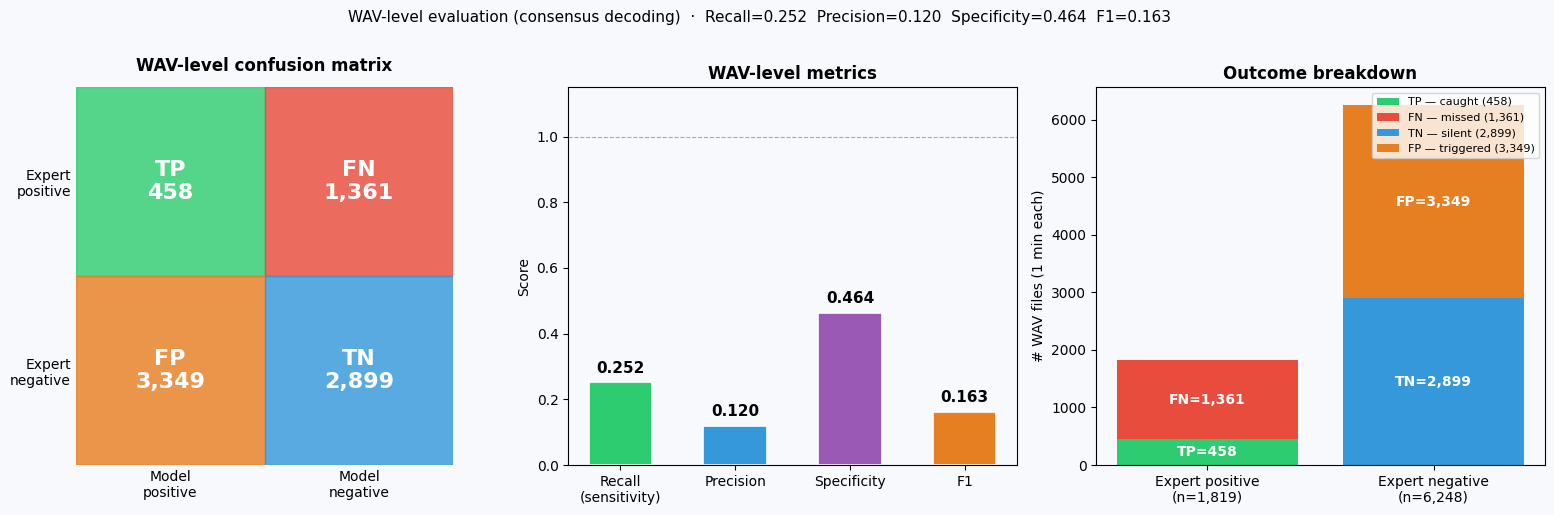

In [7]:
# ── B. Headline confusion matrix ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#f7f9fc')

# ── (1) confusion matrix tile ────────────────────────────────────────────────
ax = axes[0]
labels = [['TP', 'FN'], ['FP', 'TN']]
counts = [[TP, FN], [FP, TN]]
colors = [['#2ecc71', '#e74c3c'], ['#e67e22', '#3498db']]
ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.set_aspect('equal')
for r in range(2):
    for c in range(2):
        ax.add_patch(plt.Rectangle([c, 1-r], 1, 1, color=colors[r][c], alpha=0.82))
        ax.text(c+0.5, 1.5-r, f"{labels[r][c]}\n{counts[r][c]:,}",
                ha='center', va='center', fontsize=16, fontweight='bold', color='white')
ax.set_xticks([0.5, 1.5]); ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(['Model\npositive', 'Model\nnegative'], fontsize=10)
ax.set_yticklabels(['Expert\nnegative', 'Expert\npositive'], fontsize=10)
ax.set_title('WAV-level confusion matrix', fontsize=12, fontweight='bold', pad=12)
ax.tick_params(length=0)
for spine in ax.spines.values(): spine.set_visible(False)

# ── (2) metric bars ───────────────────────────────────────────────────────────
ax = axes[1]
metrics = {'Recall\n(sensitivity)': recall, 'Precision': precision,
           'Specificity': specificity, 'F1': f1}
mc = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22']
bars = ax.bar(list(metrics), list(metrics.values()), color=mc,
              edgecolor='white', linewidth=1.2, width=0.55)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score', fontsize=10)
ax.set_title('WAV-level metrics', fontsize=12, fontweight='bold')
ax.axhline(1.0, ls='--', lw=0.8, color='#aaa')
for bar, val in zip(bars, metrics.values()):
    lbl = f'{val:.3f}' if not np.isnan(val) else 'n/a'
    ax.text(bar.get_x()+bar.get_width()/2, (val if not np.isnan(val) else 0)+0.02,
            lbl, ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_facecolor('#f7f9fc')

# ── (3) stacked outcome bars ──────────────────────────────────────────────────
ax = axes[2]
pos_lbl = f'Expert positive\n(n={TP+FN:,})'
neg_lbl = f'Expert negative\n(n={TN+FP:,})'
ax.bar([pos_lbl], [TP],  color='#2ecc71', label=f'TP — caught ({TP:,})')
ax.bar([pos_lbl], [FN],  bottom=[TP], color='#e74c3c', label=f'FN — missed ({FN:,})')
ax.bar([neg_lbl], [TN],  color='#3498db', label=f'TN — silent ({TN:,})')
ax.bar([neg_lbl], [FP],  bottom=[TN], color='#e67e22', label=f'FP — triggered ({FP:,})')
for xpos, bot, val, lbl in [(0, TP/2, TP, f'TP={TP:,}'), (0, TP+FN/2, FN, f'FN={FN:,}'),
                             (1, TN/2, TN, f'TN={TN:,}'), (1, TN+FP/2, FP, f'FP={FP:,}')]:
    if val > 0:
        ax.text(xpos, bot, lbl, ha='center', va='center', color='white', fontweight='bold')
ax.set_ylabel('# WAV files (1 min each)', fontsize=10)
ax.set_title('Outcome breakdown', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.set_facecolor('#f7f9fc')

plt.suptitle(f'WAV-level evaluation (consensus decoding)  ·  '
             f'Recall={recall:.3f}  Precision={precision:.3f}  Specificity={specificity:.3f}  F1={f1:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


In [8]:
# ── C. Per-species breakdown ──────────────────────────────────────────────────
# For each species S (short code, as exp_top_species uses):
#   exp_WAVs        = WAVs where expert top species == S
#   model_maj_WAVs  = WAVs where model majority label == S
#   model_any_WAVs  = WAVs where S appeared in ANY firing segment
#   overlap_any     = exp_WAVs ∩ model_any_WAVs  (lenient: any-segment match)
#   overlap_maj     = exp_WAVs ∩ model_maj_WAVs  (strict: majority-label match)
#   only_expert     = exp_WAVs where model fired nothing at all (recall gap)
#   only_model_maj  = model majority says S, expert disagrees (precision gap)

rows = []
for sp in SHARED_SPECIES:
    exp_set = set(wav.loc[wav['exp_top_species'] == sp, 'wav_name'])
    maj_set = set(wav.loc[wav['model_sp_majority'] == sp, 'wav_name'])
    # model_sp_any is comma-separated; match whole tokens only
    pat = r'(?:^|, )' + sp + r'(?:,|$)'
    any_set = set(wav.loc[wav['model_sp_any'].str.contains(pat, regex=True, na=False), 'wav_name'])

    both_any  = len(exp_set & any_set)
    both_maj  = len(exp_set & maj_set)
    only_exp  = len(exp_set - any_set)
    only_mod  = len(maj_set - exp_set)

    rows.append({
        'species':        sp,
        'exp_WAVs':       len(exp_set),
        'model_maj_WAVs': len(maj_set),
        'model_any_WAVs': len(any_set),
        'overlap_any':    both_any,
        'overlap_maj':    both_maj,
        'only_expert':    only_exp,
        'only_model_maj': only_mod,
        'recall_any':     round(both_any / len(exp_set), 3) if exp_set else float('nan'),
        'recall_maj':     round(both_maj / len(exp_set), 3) if exp_set else float('nan'),
    })

sp_df = pd.DataFrame(rows).sort_values('exp_WAVs', ascending=False)
print("Per-species WAV-level breakdown (annotated WAVs only):")
print(sp_df.to_string(index=False))


Per-species WAV-level breakdown (annotated WAVs only):
species  exp_WAVs  model_maj_WAVs  model_any_WAVs  overlap_any  overlap_maj  only_expert  only_model_maj  recall_any  recall_maj
     Gg      1306               1               1            0            0         1306               1       0.000       0.000
     Tt       399              63              73            9            7          390              56       0.023       0.018
     Sc        18               0               0            0            0           18               0       0.000       0.000
     Dd         8               2               4            0            0            8               2       0.000       0.000
     Oo         0              22              25            0            0            0              22         NaN         NaN
     Gm         0               0               0            0            0            0               0         NaN         NaN
     Pm         0               0         

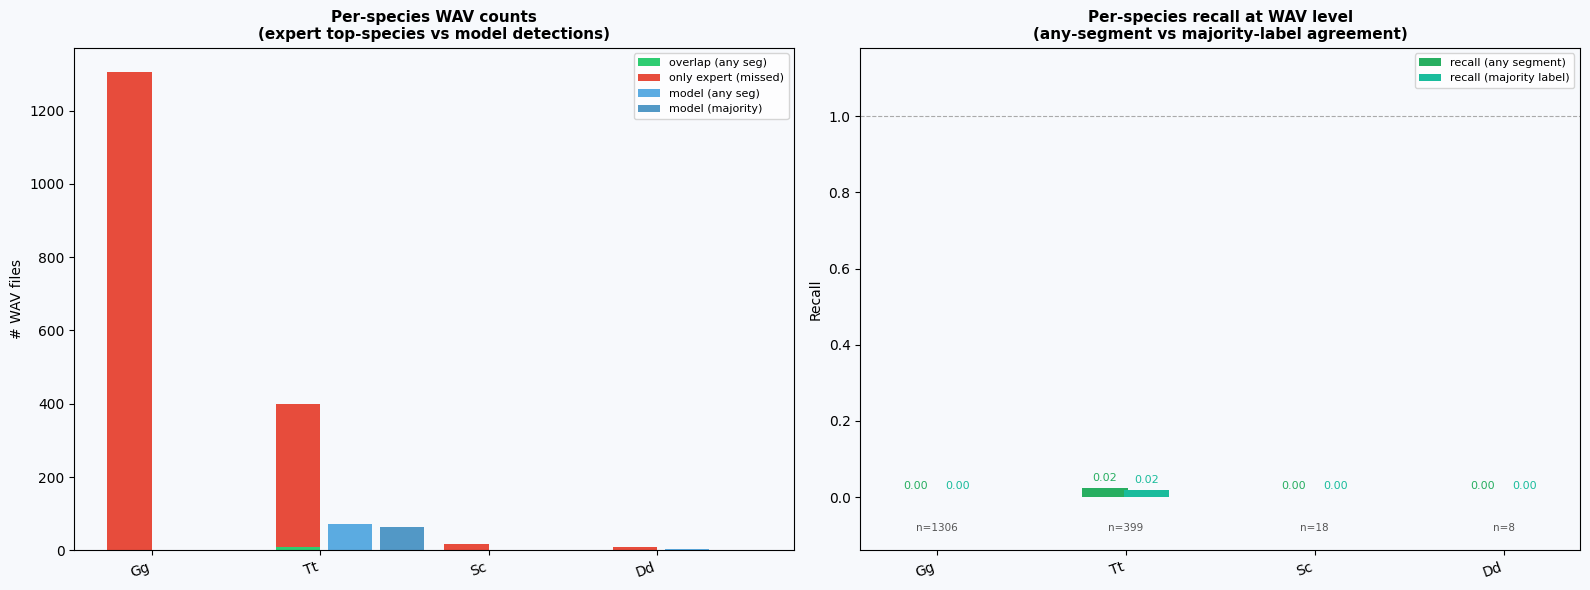

In [9]:
# ── D. Per-species visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#f7f9fc')

sp_plot = sp_df[sp_df['exp_WAVs'] > 0].copy()
sp_names = sp_plot['species'].tolist()
x = np.arange(len(sp_names)); w = 0.22

# ── (1) WAV counts: overlap / only-expert / model detections ─────────────────
ax = axes[0]
ax.bar(x,           sp_plot['overlap_any'],    w*1.2,  label='overlap (any seg)',    color='#2ecc71')
ax.bar(x,           sp_plot['only_expert'],    w*1.2,
       bottom=sp_plot['overlap_any'],                   label='only expert (missed)', color='#e74c3c')
ax.bar(x + w*1.4,   sp_plot['model_any_WAVs'],w*1.2,  label='model (any seg)',      color='#3498db', alpha=0.8)
ax.bar(x + w*1.4*2, sp_plot['model_maj_WAVs'],w*1.2,  label='model (majority)',     color='#2980b9', alpha=0.8)
ax.set_xticks(x + w*0.6); ax.set_xticklabels(sp_names, rotation=20, ha='right')
ax.set_ylabel('# WAV files', fontsize=10)
ax.set_title('Per-species WAV counts\n(expert top-species vs model detections)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.set_facecolor('#f7f9fc')

# ── (2) Per-species recall (any-seg vs majority) ──────────────────────────────
ax = axes[1]
rc_any = sp_plot['recall_any'].fillna(0)
rc_maj = sp_plot['recall_maj'].fillna(0)
ax.bar(x - w/2, rc_any, w*1.1, label='recall (any segment)',  color='#27ae60')
ax.bar(x + w/2, rc_maj, w*1.1, label='recall (majority label)', color='#1abc9c')
for i, (ra, rm, n) in enumerate(zip(rc_any, rc_maj, sp_plot['exp_WAVs'])):
    ax.text(i - w/2, ra + 0.02, f'{ra:.2f}', ha='center', fontsize=8, color='#27ae60')
    ax.text(i + w/2, rm + 0.02, f'{rm:.2f}', ha='center', fontsize=8, color='#1abc9c')
    ax.text(i, -0.09, f'n={n}', ha='center', fontsize=7.5, color='#555')
ax.set_xticks(x); ax.set_xticklabels(sp_names, rotation=20, ha='right')
ax.set_ylim(-0.14, 1.18); ax.set_ylabel('Recall', fontsize=10)
ax.axhline(1.0, ls='--', lw=0.8, color='#aaa')
ax.set_title('Per-species recall at WAV level\n(any-segment vs majority-label agreement)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.set_facecolor('#f7f9fc')

plt.tight_layout()
plt.show()


In [10]:
# ── E. False-positive / false-negative deep dive ─────────────────────────────
fp_wavs = wav[wav['outcome'] == 'FP'].copy()
fn_wavs = wav[wav['outcome'] == 'FN'].copy()

print(f"False positives : {len(fp_wavs):,} expert-negative WAVs the model triggered on")
print(f"False negatives : {len(fn_wavs):,} expert-positive WAVs the model missed entirely\n")

fp_sp = fp_wavs['model_sp_any'].str.split(', ').explode()
fp_sp = fp_sp[fp_sp.str.strip() != '']
print("Species the model fired on expert-negative WAVs (FP by species label):")
print(fp_sp.value_counts().to_string())

print()
print("Expert species in missed WAVs (FN — model detected nothing):")
print(fn_wavs['exp_top_species'].value_counts().to_string())

print()
print("Segments-per-FP-WAV stats (how many segs triggered the false alarm):")
print(fp_wavs['n_cetacean_segs'].describe().round(2).to_string())

print()
print("Uncertain segments in FN WAVs (strategies partially disagreed but didn't reach consensus):")
print(fn_wavs['n_uncertain_segs'].describe().round(2).to_string())


False positives : 3,349 expert-negative WAVs the model triggered on
False negatives : 1,361 expert-positive WAVs the model missed entirely

Species the model fired on expert-negative WAVs (FP by species label):
model_sp_any
Ambig    3316
Bp         24
Oo          6
Tt          4
Gg          1

Expert species in missed WAVs (FN — model detected nothing):
exp_top_species
Gg    984
Tt    288
Dc     52
Lo     19
Sc     12
Dd      6

Segments-per-FP-WAV stats (how many segs triggered the false alarm):
count    3349.00
mean        5.15
std         3.39
min         1.00
25%         2.00
50%         4.00
75%         8.00
max        12.00

Uncertain segments in FN WAVs (strategies partially disagreed but didn't reach consensus):
count    1361.00
mean        4.63
std         3.57
min         0.00
25%         2.00
50%         4.00
75%         7.00
max        12.00


In [11]:
# ── F. Uncertain-segment audit ────────────────────────────────────────────────
# Which FN WAVs had uncertain segments — strategies partially fired but didn't
# agree?  These are borderline misses worth opening in the inspector.
fn_with_uncertain = fn_wavs[fn_wavs['n_uncertain_segs'] > 0]
print(f"FN WAVs with ≥1 uncertain segment: {len(fn_with_uncertain):,} of {len(fn_wavs):,}")
print("  → these are borderline misses where strategies partially disagreed\n")

fn_wav_names = set(fn_with_uncertain['wav_name'])
fn_unc_segs = ann[ann['wav_name'].isin(fn_wav_names) &
                  (ann['pred_consensus'] == 'uncertain')].copy()
fn_unc_segs['pattern'] = (fn_unc_segs['pred_argmax'] + ' / ' +
                           fn_unc_segs['pred_vec']    + ' / ' +
                           fn_unc_segs['pred_pr'])
print("Top disagreement patterns in uncertain segments of missed WAVs (argmax / vec / pr):")
print(fn_unc_segs['pattern'].value_counts().head(15).to_string())


FN WAVs with ≥1 uncertain segment: 1,223 of 1,361
  → these are borderline misses where strategies partially disagreed

Top disagreement patterns in uncertain segments of missed WAVs (argmax / vec / pr):
pattern
background / Physeter_macrocephalus / background                        1876
background / Delphinidae_unknown / background                            541
background / Stenella_coeruleoalba / background                          451
Tursiops_truncatus / Physeter_macrocephalus / background                 396
Balaenoptera_acutorostrata / Balaenoptera_acutorostrata / background     379
Tursiops_truncatus / Tursiops_truncatus / background                     378
Delphinidae_unknown / Delphinidae_unknown / background                   359
background / Balaenoptera_acutorostrata / background                     331
Tursiops_truncatus / Stenella_coeruleoalba / background                  239
Physeter_macrocephalus / Physeter_macrocephalus / background             173
Delphinus_delphis 